In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-05-visualization-first-models-and-ML\datasets\students.csv"

In [6]:
df = pd.read_csv(path, usecols=['study_hours', 'final_marks'])

In [7]:
df

,study_hours,final_marks
0,8.1,68.5
1,5.2,54.4
2,4.0,68.7
3,2.5,56.8
4,7.7,68.8
...,...,...
179,5.5,56.0
180,3.5,63.5
181,1.4,65.3
182,7.9,71.5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  179 non-null    float64
 1   final_marks  184 non-null    float64
dtypes: float64(2)
memory usage: 3.0 KB


<Axes: xlabel='study_hours'>

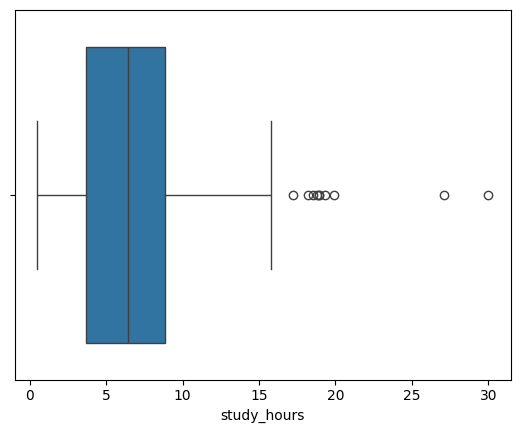

In [11]:
sns.boxplot(data=df, x='study_hours')

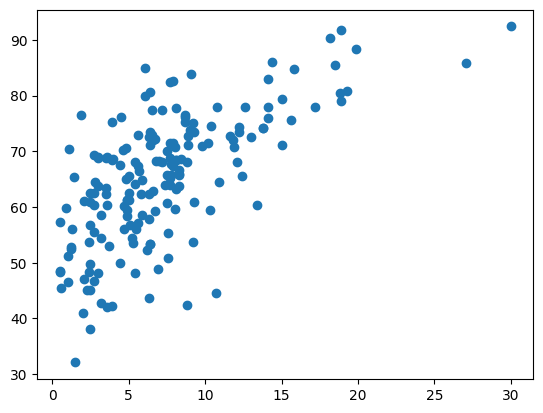

In [12]:
plt.scatter(df['study_hours'], df['final_marks'])

In [13]:
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].median())

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  184 non-null    float64
 1   final_marks  184 non-null    float64
dtypes: float64(2)
memory usage: 3.0 KB


In [15]:
df.shape

(184, 2)

In [16]:
184/100 * 80

147.20000000000002

In [19]:
x_train = df['study_hours'].iloc[0:147]

In [20]:
x_train

0       8.1
1       5.2
2       4.0
3       2.5
4       7.7
       ... 
142    17.2
143    18.9
144     6.2
145     3.5
146    19.9
Name: study_hours, Length: 147, dtype: float64

In [22]:
y_train = df['final_marks'].iloc[0:147]

In [23]:
y_train

0      68.5
1      54.4
2      68.7
3      56.8
4      68.8
       ... 
142    78.0
143    79.1
144    52.3
145    62.3
146    88.4
Name: final_marks, Length: 147, dtype: float64

In [24]:
x_test = df['study_hours'].iloc[147:]
y_test = df['final_marks'].iloc[147:]

In [31]:
x_train

0       8.1
1       5.2
2       4.0
3       2.5
4       7.7
       ... 
142    17.2
143    18.9
144     6.2
145     3.5
146    19.9
Name: study_hours, Length: 147, dtype: float64

In [32]:
y_train

0      68.5
1      54.4
2      68.7
3      56.8
4      68.8
       ... 
142    78.0
143    79.1
144    52.3
145    62.3
146    88.4
Name: final_marks, Length: 147, dtype: float64

In [33]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [ ]:
class LinearRegression:
    count = 0
    def __init__(self, m=0, b=0, alpha=0):
        self.alpha = alpha
        self.m = m
        self.b = b
        self.history = []

    def predict(self, x):
        return self.m * x + self.b 

    def cost(self, x, y):
        y_hat = self.predict(x)
        loss = (1/(2*len(x))) * np.sum((y_hat - y)**2)
        return loss

    def gradient(self, x, y):
        y_hat = self.predict(x)
        error = y_hat - y
        gm = np.sum(error*x)/len(x)
        gb = np.sum(error)/len(x)
        return gm, gb
        

    def run_epoch(self, x, y):
        gm, gb = self.gradient(x, y)
        self.m -= self.alpha * gm
        self.b -= self.alpha * gb
        loss = self.cost(x, y)
        self.history.append((self.m, self.b, loss))

        self.count += 1
        print(f"Epoch : {self.count} -- m : {self.m}  --  b : {self.b} : cost : {loss}")
    

In [100]:
m = 2
b = 0
alpha = 0.05

model = LinearRegression(m, b, alpha)

In [101]:
model.m

2

In [102]:
model.b

0

In [103]:
model.alpha

0.05

In [104]:
model.run_epoch(x_train, y_train)

Epoch : 1 -- m : 19.65003741496599  --  b : 2.5313945578231296 : cost : 7133.121972587308


In [105]:
model.history

[(19.65003741496599, 2.5313945578231296, 7133.121972587308)]

In [106]:
model.run_epoch(x_train, y_train)

Epoch : 2 -- m : -30.702713906254356  --  b : -1.444809445022908 : cost : 53934.77177418184


In [107]:
model.run_epoch(x_train, y_train)

Epoch : 3 -- m : 111.77234820845845  --  b : 12.981857765649245 : cost : 430323.85338825


In [108]:
model.alpha = 0.01 

In [109]:
model.run_epoch(x_train, y_train)

Epoch : 4 -- m : 30.914972811363697  --  b : 5.421105248484556 : cost : 23770.29167612228


In [110]:
model.run_epoch(x_train, y_train)

Epoch : 5 -- m : 12.071897873401074  --  b : 3.7824435428569574 : cost : 1716.078803927575


In [111]:
model.run_epoch(x_train, y_train)

Epoch : 6 -- m : 7.671775321962227  --  b : 3.5226381380652585 : cost : 517.4332983245265


In [112]:
model.run_epoch(x_train, y_train)

Epoch : 7 -- m : 6.635402475697025  --  b : 3.58358658731633 : cost : 450.0253335605429


In [113]:
for i in range(8, 500):
    model.run_epoch(x_train, y_train)

Epoch : 8 -- m : 6.38247120608138  --  b : 3.7188616539997406 : cost : 443.9913824703953
Epoch : 9 -- m : 6.31203655590538  --  b : 3.8710724493683215 : cost : 441.3010997654429
Epoch : 10 -- m : 6.284140410641014  --  b : 4.026853993223494 : cost : 438.8067822822931
Epoch : 11 -- m : 6.266186898690427  --  b : 4.183094783735454 : cost : 436.33760585035907
Epoch : 12 -- m : 6.250584444154573  --  b : 4.339071315175783 : cost : 433.8842151556183
Epoch : 13 -- m : 6.235564885533639  --  b : 4.494616234289882 : cost : 431.44601363818896
Epoch : 14 -- m : 6.220716314756399  --  b : 4.649691710257616 : cost : 429.0228803707353
Epoch : 15 -- m : 6.205942690826654  --  b : 4.804290074042484 : cost : 426.61472077192013
Epoch : 16 -- m : 6.1912215374358075  --  b : 4.958410677650383 : cost : 424.22144223336153
Epoch : 17 -- m : 6.176547511573129  --  b : 5.112054504741871 : cost : 421.8429527942573
Epoch : 18 -- m : 6.16191926084906  --  b : 5.265222915473291 : cost : 419.479161066156
Epoch : 1

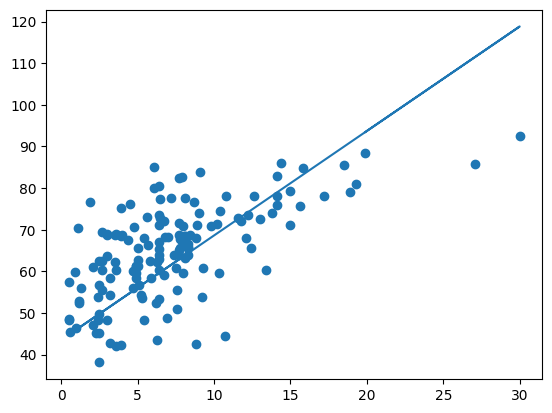

In [114]:
plt.scatter(x_train, y_train)
y_hat = model.predict(x_train)
plt.plot(x_train, y_hat)

In [115]:
model.m

2.5106705942548646

In [116]:
model.b

43.496742790865405

In [117]:
model_pred_x_test = model.predict(x_test)

In [118]:
model_pred_x_test

array([52.78622399, 65.33957696, 89.19094761, 59.56503459, 60.06716871,
       62.32677225, 65.33957696, 70.86305227, 57.55649812, 48.51808398,
       78.14399699, 66.84597932, 47.26274868, 50.2755534 , 73.37372286,
       61.57357107, 62.32677225, 57.054364  , 90.69734996, 66.59491226,
       59.31396753, 50.52662045, 74.12692404, 65.84171108, 58.3096993 ,
       54.54369341, 46.00741339, 90.94841702, 55.54796164, 57.55649812,
       55.04582752, 49.77341928, 57.30543106, 52.28408987, 47.01168162,
       63.33104049, 59.31396753])

In [119]:
y_test

array([53. , 76.1, 90.4, 53.4, 62.8, 70.1, 75.3, 64.4, 57.2, 40.9, 74.1,
       73.5, 32.1, 46.8, 70.8, 68. , 65.7, 64.1, 80.5, 75.1, 72.5, 64.5,
       74.4, 72.7, 64.8, 49.9, 51.2, 91.8, 65.1, 67.4, 70.3, 60.9, 56. ,
       63.5, 65.3, 71.5, 57.8])

In [123]:
pd.DataFrame([model_pred_x_test, y_test])

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,52.786224,65.339577,89.190948,59.565035,60.067169,62.326772,65.339577,70.863052,57.556498,48.518084,...,90.948417,55.547962,57.556498,55.045828,49.773419,57.305431,52.28409,47.011682,63.33104,59.313968
1,53.000000,76.100000,90.400000,53.400000,62.800000,70.100000,75.300000,64.400000,57.200000,40.900000,...,91.800000,65.100000,67.400000,70.300000,60.900000,56.000000,63.50000,65.300000,71.50000,57.800000


In [121]:
x_test.shape

(37,)

In [124]:
model.cost(x_test, y_test)

35.046589022792624

In [148]:
class LinearRegression:
    count = 0
    def __init__(self, m=0, b=0, alpha=0):
        self.alpha = alpha
        self.m = m
        self.b = b
        self.history = []

    def predict(self, x):
        return self.m * x + self.b 

    def cost(self, x, y):
        y_hat = self.predict(x)
        loss = (1/(2*len(x))) * np.sum((y_hat - y)**2)
        return loss

    def gradient(self, x, y):
        y_hat = self.predict(x)
        error = y_hat - y
        gm = np.sum(error*x)/len(x)
        gb = np.sum(error)/len(x)
        return gm, gb
        

    def run_epoch(self, x, y):
        gm, gb = self.gradient(x, y)
        self.m -= self.alpha * gm
        self.b -= self.alpha * gb
        loss = self.cost(x, y)
        self.history.append((self.m, self.b, loss))

        self.count += 1
        print(f"Epoch : {self.count} -- m : {self.m}  --  b : {self.b} : cost : {loss}")


    def fit(self, epoch, x, y):
        for i in range(1, epoch+1):
            self.run_epoch(x, y)
    

In [149]:
model = LinearRegression(1, 1, 0.01)

In [150]:
model.fit(700, x_train, y_train)

Epoch : 1 -- m : 5.217899319727891  --  b : 1.5685850340136054 : cost : 540.4867629689259
Epoch : 2 -- m : 6.18824800546439  --  b : 1.8265042729973622 : cost : 477.30897983634907
Epoch : 3 -- m : 6.402290460531535  --  b : 2.0116821687022117 : cost : 471.3436067755772
Epoch : 4 -- m : 6.440228782476295  --  b : 2.1795317054846475 : cost : 468.49716747763057
Epoch : 5 -- m : 6.437189920344199  --  b : 2.3429595739472124 : cost : 465.83549156037634
Epoch : 6 -- m : 6.4246443595345335  --  b : 2.5049728920625807 : cost : 463.1993309372386
Epoch : 7 -- m : 6.409921353631175  --  b : 2.66627319785289 : cost : 460.5799521230457
Epoch : 8 -- m : 6.3947277471070665  --  b : 2.8270250640529615 : cost : 457.9767862566912
Epoch : 9 -- m : 6.379460945133861  --  b : 2.987268002364806 : cost : 455.38970792078453
Epoch : 10 -- m : 6.364213389344787  --  b : 3.147012394546411 : cost : 452.8186163350163
Epoch : 11 -- m : 6.349006496767485  --  b : 3.306261834442132 : cost : 450.2634126361395
Epoch : 

In [153]:
x_test_pred = model.predict(x_test)

In [154]:
x_test_pred

array([56.05077657, 66.19337366, 85.46430813, 61.527779  , 61.93348288,
       63.75915036, 66.19337366, 70.65611638, 59.90496346, 52.60229356,
       76.53882269, 67.41048531, 51.58803385, 54.02225715, 72.68463579,
       63.15059453, 63.75915036, 59.49925958, 86.68141978, 67.20763337,
       61.32492705, 54.22510909, 73.29319162, 66.59907754, 60.51351929,
       57.47074016, 50.57377414, 86.88427172, 58.28214793, 59.90496346,
       57.87644404, 53.61655327, 59.70211152, 55.64507269, 51.38518191,
       64.57055812, 61.32492705])

In [155]:
y_test

array([53. , 76.1, 90.4, 53.4, 62.8, 70.1, 75.3, 64.4, 57.2, 40.9, 74.1,
       73.5, 32.1, 46.8, 70.8, 68. , 65.7, 64.1, 80.5, 75.1, 72.5, 64.5,
       74.4, 72.7, 64.8, 49.9, 51.2, 91.8, 65.1, 67.4, 70.3, 60.9, 56. ,
       63.5, 65.3, 71.5, 57.8])

In [156]:
model.cost(x_test, y_test)

28.93654527448539

In [138]:
np.min(y_train)

38.1

In [139]:
np.max(y_train)

92.4

In [140]:
np.min(y_test)

32.1

In [141]:
np.max(y_test)

91.8

In [157]:
model.history

[(5.217899319727891, 1.5685850340136054, 540.4867629689259),
 (6.18824800546439, 1.8265042729973622, 477.30897983634907),
 (6.402290460531535, 2.0116821687022117, 471.3436067755772),
 (6.440228782476295, 2.1795317054846475, 468.49716747763057),
 (6.437189920344199, 2.3429595739472124, 465.83549156037634),
 (6.4246443595345335, 2.5049728920625807, 463.1993309372386),
 (6.409921353631175, 2.66627319785289, 460.5799521230457),
 (6.3947277471070665, 2.8270250640529615, 457.9767862566912),
 (6.379460945133861, 2.987268002364806, 455.38970792078453),
 (6.364213389344787, 3.147012394546411, 452.8186163350163),
 (6.349006496767485, 3.306261834442132, 450.2634126361395),
 (6.333845143391943, 3.465018331375659, 447.7239986420294),
 (6.318730353204103, 3.623283522013515, 445.20027678107925),
 (6.303662253416877, 3.781058952615105, 442.6921500848256),
 (6.2886407627321566, 3.9383461447789676, 440.199522184026),
 (6.273665751633601, 4.095146610766007, 437.7222973049461),
 (6.258737079717204, 4.2514

In [158]:
len(model.history)

700

In [159]:

losses = [epoch[2] for epoch in model.history]

In [160]:
epochs = list(range(1, 701))

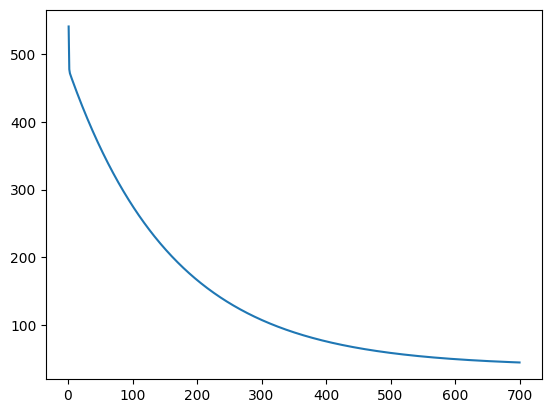

In [161]:
plt.plot(epochs, losses)

In [162]:
def predict(x, m, b):
    return m * x + b

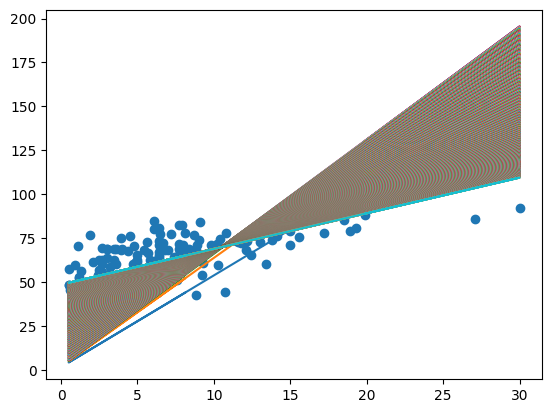

In [164]:
plt.scatter(x_train, y_train)

for epoch in model.history:
    m = epoch[0]
    b = epoch[1]
    y_hat = predict(x_train, m, b)

    plt.plot(x_train, y_hat)

plt.show()